# FICO Score Quantization — Optimal Bucket Construction

    Task: Map continuous FICO scores (300–850) to discrete rating buckets
            that best capture default risk, using two optimisation objectives:
    
      Method 1 — Minimise Mean Squared Error (MSE)
                 Treat bucketing as an approximation problem: find boundaries
                 such that within each bucket, all scores are represented by
                 the bucket mean with minimum squared deviation.
    
      Method 2 — Maximise Log-Likelihood (LL) via Dynamic Programming
                 Find boundaries that maximise the log-likelihood of observed
                 defaults given the within-bucket default rate, using a DP
                 approach that solves the problem in O(n² · B) time.
    
    Output
    
      - Rating map function: fico_to_rating(score, method, n_buckets)
      - Comparison plots across bucket counts
      - Summary tables for both methods


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv("Loan_Data.csv")
fico   = df["fico_score"].values
default = df["default"].values

print(f"Records     : {len(fico):,}")
print(f"FICO range  : {fico.min()} – {fico.max()}")
print(f"Default rate: {default.mean():.2%}")


Records     : 10,000
FICO range  : 408 – 850
Default rate: 18.51%


# EDA: FICO vs Default

In [3]:
# Rolling default rate by FICO
fico_df = pd.DataFrame({"fico": fico, "default": default}).sort_values("fico")
fico_df["rolling_dr"] = fico_df["default"].rolling(200, center=True, min_periods=50).mean()

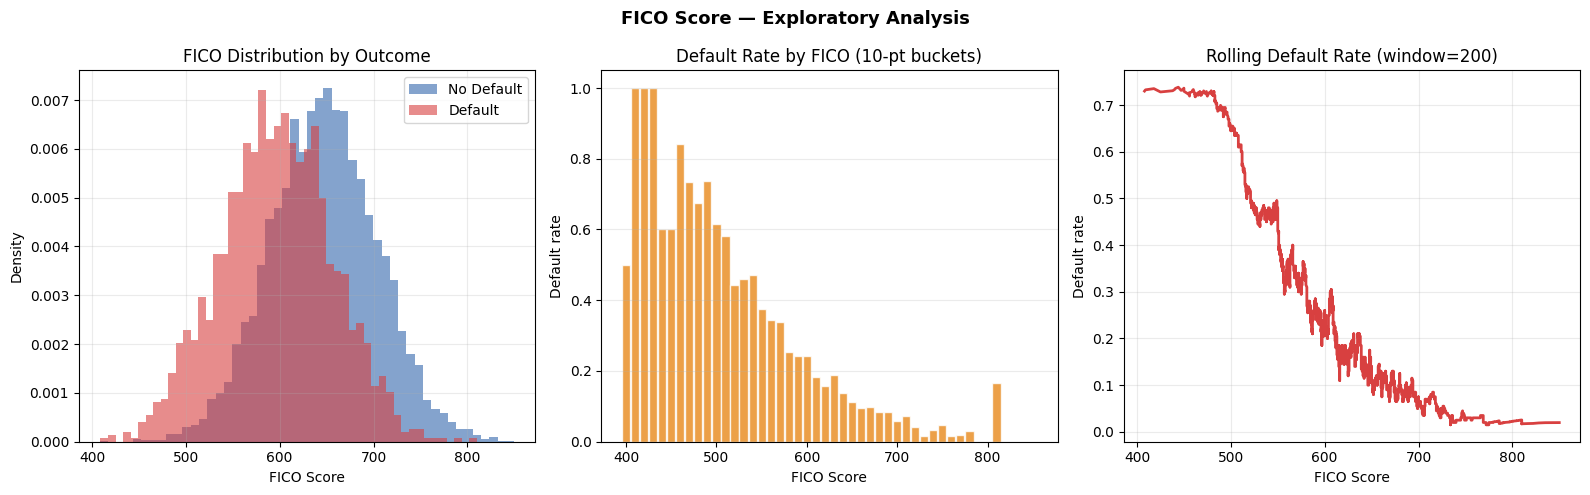

In [4]:
# Default rate in 10-point FICO buckets
fico_df["fico_10"] = (fico_df["fico"] // 10) * 10
bucket_dr = fico_df.groupby("fico_10").agg(
    n=("default", "count"),
    k=("default", "sum")
).reset_index()
bucket_dr["dr"] = bucket_dr["k"] / bucket_dr["n"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("FICO Score — Exploratory Analysis", fontsize=13, fontweight="bold")

ax = axes[0]
ax.hist(fico[default == 0], bins=50, alpha=0.6, color="#3266ad",
        density=True, label="No Default")
ax.hist(fico[default == 1], bins=50, alpha=0.6, color="#d84040",
        density=True, label="Default")
ax.set_title("FICO Distribution by Outcome")
ax.set_xlabel("FICO Score"); ax.set_ylabel("Density")
ax.legend(); ax.grid(True, alpha=0.25)

ax = axes[1]
ax.bar(bucket_dr["fico_10"], bucket_dr["dr"], width=9,
       color="#e8891a", alpha=0.8, edgecolor="white")
ax.set_title("Default Rate by FICO (10-pt buckets)")
ax.set_xlabel("FICO Score"); ax.set_ylabel("Default rate")
ax.grid(True, alpha=0.25, axis="y")

ax = axes[2]
ax.plot(fico_df["fico"], fico_df["rolling_dr"],
        color="#d84040", linewidth=2)
ax.set_title("Rolling Default Rate (window=200)")
ax.set_xlabel("FICO Score"); ax.set_ylabel("Default rate")
ax.grid(True, alpha=0.25)

plt.tight_layout()

# Method 1: MSE-optimal bucketing

In [5]:
def mse_optimal_buckets(scores, n_buckets):
    """
    Find bucket boundaries that minimise total within-bucket MSE.

    Uses a 1-D k-means style DP approach:
      - Pre-compute cost[i][j] = MSE of placing scores[i..j] in one bucket
      - DP recurrence: dp[b][j] = min over all split points s of
            dp[b-1][s] + cost[s+1][j]

    Parameters
    ----------
    scores   : 1-D array of FICO scores (need not be sorted)
    n_buckets: number of buckets B

    Returns
    -------
    boundaries : list of (lo, hi) inclusive tuples, length B
    boundaries_vals: list of B+1 boundary score values
    mse_total  : float, total weighted MSE
    """
    sorted_scores = np.sort(scores)
    n = len(sorted_scores)

    # Build prefix sums for O(1) segment mean & variance
    prefix_sum  = np.zeros(n + 1)
    prefix_sum2 = np.zeros(n + 1)
    for i, s in enumerate(sorted_scores):
        prefix_sum[i+1]  = prefix_sum[i]  + s
        prefix_sum2[i+1] = prefix_sum2[i] + s * s

    def segment_mse(i, j):
        """MSE of sorted_scores[i:j+1] around their mean."""
        cnt  = j - i + 1
        sm   = prefix_sum[j+1]  - prefix_sum[i]
        sm2  = prefix_sum2[j+1] - prefix_sum2[i]
        mean = sm / cnt
        return (sm2 - cnt * mean**2) / cnt   # within-segment variance

    # DP: dp[b][j] = min total MSE using b buckets on scores[0..j]
    INF = float("inf")
    dp   = np.full((n_buckets + 1, n), INF)
    split = np.full((n_buckets + 1, n), -1, dtype=int)

    # Base case: 1 bucket covering scores[0..j]
    for j in range(n):
        dp[1][j] = segment_mse(0, j) * (j + 1)

    # Fill DP table
    for b in range(2, n_buckets + 1):
        for j in range(b - 1, n):
            for s in range(b - 2, j):
                cost = dp[b-1][s] + segment_mse(s+1, j) * (j - s)
                if cost < dp[b][j]:
                    dp[b][j] = cost
                    split[b][j] = s

    # Backtrack to find cut points
    cuts = []
    j = n - 1
    b = n_buckets
    while b > 1:
        s = split[b][j]
        cuts.append(s)
        j = s
        b -= 1
    cuts = sorted(cuts)

    # Build boundary values from sorted score indices
    boundary_vals = [sorted_scores[0] - 1]
    for c in cuts:
        boundary_vals.append((sorted_scores[c] + sorted_scores[c+1]) / 2)
    boundary_vals.append(sorted_scores[-1] + 1)

    total_mse = dp[n_buckets][n - 1] / n
    return boundary_vals, total_mse


# Quick O(n²B) DP is fine for demonstration; we use unique FICO values to shrink n
unique_fico = np.sort(np.unique(fico))
print(f"Unique FICO values: {len(unique_fico)}")

N_BUCKETS_LIST = [5, 7, 10]

mse_results = {}
for nb in N_BUCKETS_LIST:
    bounds, mse_val = mse_optimal_buckets(unique_fico, nb)
    mse_results[nb] = {"boundaries": bounds, "mse": mse_val}
    print(f"\n  {nb} buckets  |  MSE = {mse_val:.2f}")
    print(f"  Boundaries: {[round(b) for b in bounds]}")


Unique FICO values: 374

  5 buckets  |  MSE = 545.75
  Boundaries: [407, 516, 594, 670, 748, 851]

  7 buckets  |  MSE = 293.34
  Boundaries: [407, 492, 548, 604, 660, 716, 772, 851]

  10 buckets  |  MSE = 152.23
  Boundaries: [407, 472, 512, 552, 592, 632, 672, 712, 752, 792, 851]


# Method 2: Log-Likelihood via Dynamic Programming

In [6]:

"""
Maximise:
    LL = Σ_i  [ k_i * log(p_i) + (n_i - k_i) * log(1 - p_i) ]

where for each bucket i:
    n_i = number of borrowers
    k_i = number of defaults
    p_i = k_i / n_i  (MLE default probability)

A bucket with p_i = 0 or p_i = 1 gives -inf; we add a small
Laplace smoothing (0.5 pseudo-count) to handle edge cases.

DP formulation
--------------
  Sort records by FICO score.
  Let ll_cost(i, j) = log-likelihood contribution of placing
      sorted records[i..j] into one bucket.
  dp[b][j] = max total LL using b buckets on records[0..j]
"""

# Sort data by FICO
sort_idx    = np.argsort(fico)
fico_sorted = fico[sort_idx]
def_sorted  = default[sort_idx]
n_all       = len(fico_sorted)

# Prefix sums of defaults and counts on sorted array
prefix_n = np.arange(n_all + 1)          # prefix count (trivial)
prefix_k = np.zeros(n_all + 1, dtype=int)
for i, d in enumerate(def_sorted):
    prefix_k[i+1] = prefix_k[i] + d

EPS = 0.5   # Laplace smoothing

def ll_segment(i, j):
    """Log-likelihood of sorted records[i:j+1] in one bucket."""
    n = j - i + 1
    k = prefix_k[j+1] - prefix_k[i]
    # Smoothed
    p = (k + EPS) / (n + 2 * EPS)
    return k * np.log(p) + (n - k) * np.log(1 - p)

def ll_optimal_buckets(n_buckets):
    """
    DP to maximise total log-likelihood with n_buckets buckets.
    Works on the full sorted dataset (not just unique FICO values)
    to correctly weight by population density.
    """
    INF = float("-inf")
    # To keep DP tractable: sub-sample to unique FICO boundaries
    # (cuts can only sit at unique FICO transitions)
    unique_scores, inv = np.unique(fico_sorted, return_inverse=True)
    U = len(unique_scores)

    # Map unique score indices back to sorted-data indices
    # last_idx[u] = last position in sorted data with fico == unique_scores[u]
    last_idx  = np.searchsorted(fico_sorted, unique_scores, side="right") - 1
    first_idx = np.searchsorted(fico_sorted, unique_scores, side="left")

    # dp[b][u] = best LL using b buckets on data[0 .. last_idx[u]]
    dp    = np.full((n_buckets + 1, U), INF)
    split = np.full((n_buckets + 1, U), -1, dtype=int)

    # Base case: 1 bucket covers data[0 .. last_idx[u]]
    for u in range(U):
        dp[1][u] = ll_segment(0, last_idx[u])

    # Fill
    for b in range(2, n_buckets + 1):
        for u in range(b - 1, U):
            for s in range(b - 2, u):
                # Bucket b covers data[first_idx[s+1] .. last_idx[u]]
                start = first_idx[s + 1]
                val   = dp[b-1][s] + ll_segment(start, last_idx[u])
                if val > dp[b][u]:
                    dp[b][u] = val
                    split[b][u] = s

    # Backtrack
    cuts_u = []
    u = U - 1
    b = n_buckets
    while b > 1:
        s = split[b][u]
        cuts_u.append(s)
        u = s
        b -= 1
    cuts_u = sorted(cuts_u)

    # Boundary values: midpoint between adjacent unique FICO scores
    boundary_vals = [unique_scores[0] - 1]
    for cu in cuts_u:
        boundary_vals.append((unique_scores[cu] + unique_scores[cu + 1]) / 2)
    boundary_vals.append(unique_scores[-1] + 1)

    return boundary_vals, dp[n_buckets][U - 1]


ll_results = {}
for nb in N_BUCKETS_LIST:
    print(f"\n  Computing LL-optimal bucketing for {nb} buckets …", end=" ", flush=True)
    bounds, ll_val = ll_optimal_buckets(nb)
    ll_results[nb] = {"boundaries": bounds, "ll": ll_val}
    print(f"LL = {ll_val:.2f}")
    print(f"  Boundaries: {[round(b) for b in bounds]}")



  Computing LL-optimal bucketing for 5 buckets … LL = -4255.38
  Boundaries: [407, 520, 580, 640, 696, 851]

  Computing LL-optimal bucketing for 7 buckets … LL = -4229.61
  Boundaries: [407, 520, 552, 580, 612, 650, 720, 851]

  Computing LL-optimal bucketing for 10 buckets … LL = -4217.87
  Boundaries: [407, 520, 552, 580, 612, 650, 696, 732, 752, 754, 851]


# Build rating map function

In [7]:
def fico_to_rating(score, method="log_likelihood", n_buckets=5):
    """
    Map a FICO score to an integer rating.

    Rating 1 = best credit (lowest default risk)
    Rating n_buckets = worst credit (highest default risk)

    Parameters
    ----------
    score     : int or float   FICO score of borrower
    method    : str            'mse' or 'log_likelihood'
    n_buckets : int            number of rating categories (default 5)

    Returns
    -------
    int : rating label 1 … n_buckets
    """
    if n_buckets not in N_BUCKETS_LIST:
        raise ValueError(f"n_buckets must be one of {N_BUCKETS_LIST}. "
                         f"Re-run optimisation for other values.")
    if method == "mse":
        bounds = mse_results[n_buckets]["boundaries"]
    elif method == "log_likelihood":
        bounds = ll_results[n_buckets]["boundaries"]
    else:
        raise ValueError("method must be 'mse' or 'log_likelihood'")

    # Buckets are ordered low→high FICO; rating 1 = highest FICO = lowest risk
    for i in range(len(bounds) - 1):
        if bounds[i] < score <= bounds[i + 1]:
            # Invert: bucket 0 (best FICO) → rating 1
            return n_buckets - i

    # Edge: score <= minimum FICO
    return n_buckets


In [8]:
# Demo
print("\nDemo: fico_to_rating()")
for score in [420, 550, 620, 680, 730, 790, 850]:
    r_ll  = fico_to_rating(score, method="log_likelihood", n_buckets=5)
    r_mse = fico_to_rating(score, method="mse",            n_buckets=5)
    print(f"  FICO {score:3d}  →  LL rating: {r_ll}  |  MSE rating: {r_mse}")


Demo: fico_to_rating()
  FICO 420  →  LL rating: 5  |  MSE rating: 5
  FICO 550  →  LL rating: 4  |  MSE rating: 4
  FICO 620  →  LL rating: 3  |  MSE rating: 3
  FICO 680  →  LL rating: 2  |  MSE rating: 2
  FICO 730  →  LL rating: 1  |  MSE rating: 2
  FICO 790  →  LL rating: 1  |  MSE rating: 1
  FICO 850  →  LL rating: 1  |  MSE rating: 1


# Compare methods: default rate per bucket

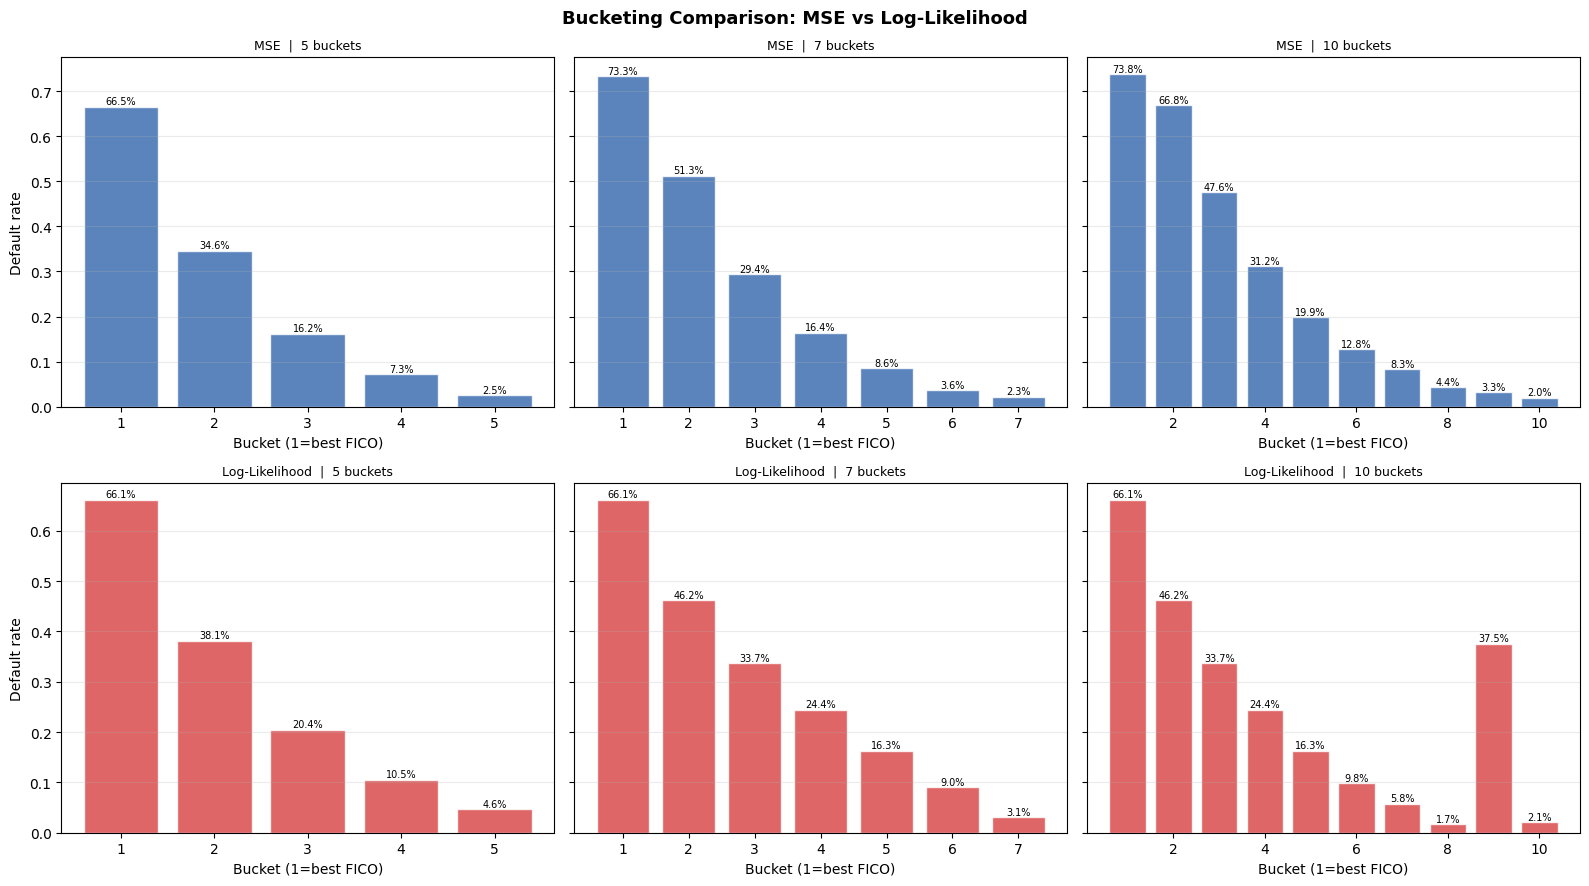

In [9]:
def bucket_stats(scores, defaults, boundaries):
    """Return DataFrame with per-bucket stats given boundary list."""
    rows = []
    for i in range(len(boundaries) - 1):
        lo, hi = boundaries[i], boundaries[i+1]
        mask = (scores > lo) & (scores <= hi)
        n = mask.sum()
        k = defaults[mask].sum()
        mean_fico = scores[mask].mean() if n > 0 else 0
        rows.append({
            "bucket":    i + 1,
            "lo":        round(lo),
            "hi":        round(hi),
            "n":         n,
            "defaults":  k,
            "default_rate": k / n if n > 0 else 0,
            "mean_fico": round(mean_fico, 1),
        })
    return pd.DataFrame(rows)

fig, axes = plt.subplots(2, len(N_BUCKETS_LIST),
                         figsize=(16, 9), sharey="row")
fig.suptitle("Bucketing Comparison: MSE vs Log-Likelihood", fontsize=13, fontweight="bold")

pal_mse = "#3266ad"
pal_ll  = "#d84040"

for col_i, nb in enumerate(N_BUCKETS_LIST):

    mse_stats = bucket_stats(fico, default, mse_results[nb]["boundaries"])
    ll_stats  = bucket_stats(fico, default, ll_results[nb]["boundaries"])

    # Row 0 – MSE
    ax = axes[0][col_i]
    ax.bar(mse_stats["bucket"], mse_stats["default_rate"],
           color=pal_mse, alpha=0.8, edgecolor="white")
    ax.set_title(f"MSE  |  {nb} buckets", fontsize=9)
    ax.set_xlabel("Bucket (1=best FICO)")
    if col_i == 0:
        ax.set_ylabel("Default rate")
    ax.grid(True, alpha=0.25, axis="y")
    for _, row in mse_stats.iterrows():
        ax.text(row["bucket"], row["default_rate"] + 0.005,
                f"{row['default_rate']:.1%}", ha="center", fontsize=7)

    # Row 1 – LL
    ax = axes[1][col_i]
    ax.bar(ll_stats["bucket"], ll_stats["default_rate"],
           color=pal_ll, alpha=0.8, edgecolor="white")
    ax.set_title(f"Log-Likelihood  |  {nb} buckets", fontsize=9)
    ax.set_xlabel("Bucket (1=best FICO)")
    if col_i == 0:
        ax.set_ylabel("Default rate")
    ax.grid(True, alpha=0.25, axis="y")
    for _, row in ll_stats.iterrows():
        ax.text(row["bucket"], row["default_rate"] + 0.005,
                f"{row['default_rate']:.1%}", ha="center", fontsize=7)

plt.tight_layout()

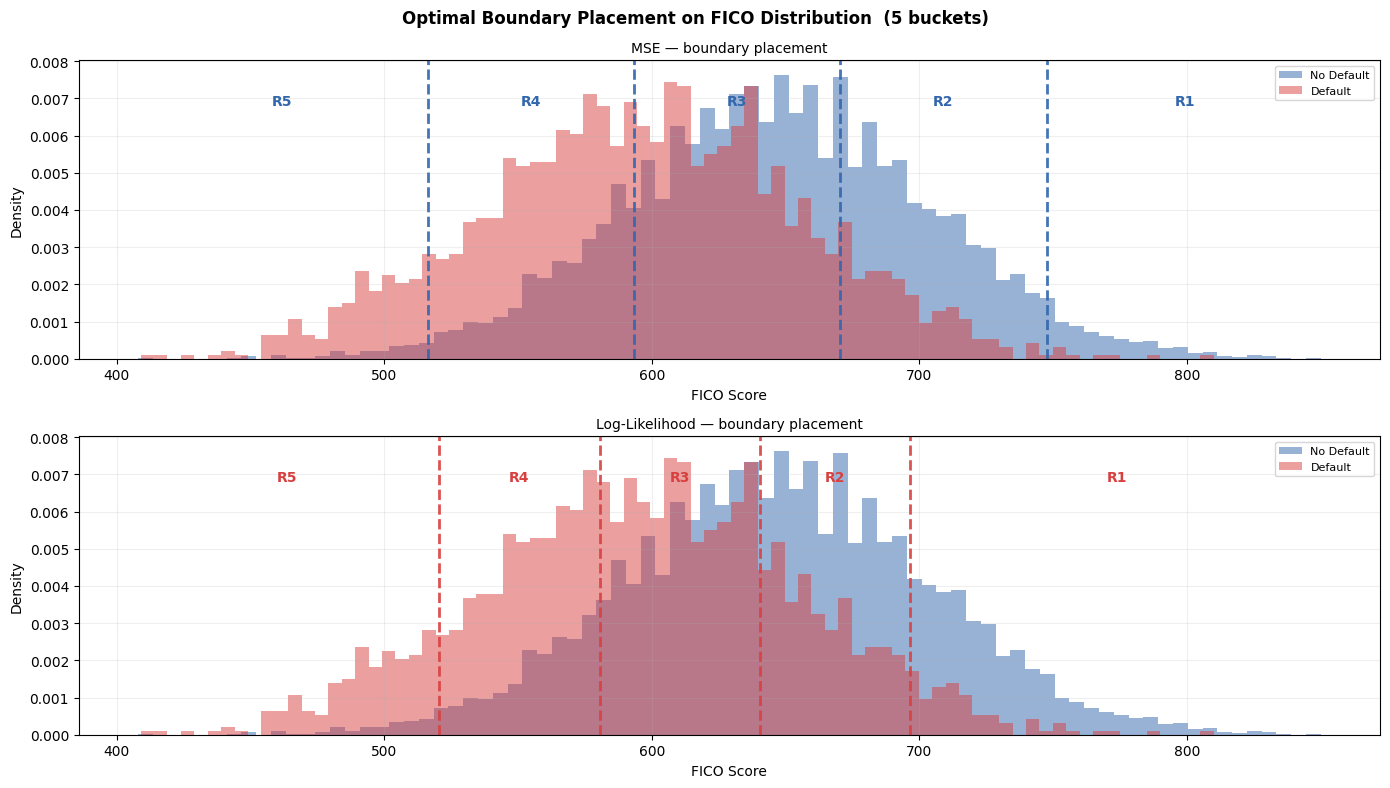

In [10]:
# Boundary visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Optimal Boundary Placement on FICO Distribution  (5 buckets)",
             fontsize=12, fontweight="bold")
fico_range = np.linspace(fico.min(), fico.max(), 400)
DEMO_NB = 5

for ax_i, (method, bounds_dict, color, label) in enumerate([
    ("mse",            mse_results, pal_mse, "MSE"),
    ("log_likelihood", ll_results,  pal_ll,  "Log-Likelihood"),
]):
    ax = axes[ax_i]
    bounds = bounds_dict[DEMO_NB]["boundaries"]

    ax.hist(fico[default == 0], bins=80, alpha=0.5, color="#3266ad",
            density=True, label="No Default")
    ax.hist(fico[default == 1], bins=80, alpha=0.5, color="#d84040",
            density=True, label="Default")

    for b in bounds[1:-1]:
        ax.axvline(b, color=color, linewidth=2.0, linestyle="--", alpha=0.9)

    # Annotate bucket centres
    for i in range(len(bounds) - 1):
        mid = (bounds[i] + bounds[i+1]) / 2
        ax.text(mid, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 0.03,
                f"R{DEMO_NB - i}", ha="center", fontsize=10,
                color=color, fontweight="bold")

    ax.set_title(f"{label} — boundary placement", fontsize=10)
    ax.set_xlabel("FICO Score"); ax.set_ylabel("Density")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()